<a href="https://colab.research.google.com/github/sa8692/Silver-Gold-Ratio-Trade/blob/main/GoldSilverCointegration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Find Packages for Cointegration Test
#General Timeframe and then Analysis for Periods of Instability
#Establish bimodal ratio and establish that it fluctuates between those two means
#Will I have to establish exclusivity?

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statistics as stats
from pandas_datareader.data import DataReader
from datetime import datetime
from statsmodels.tsa.stattools import coint

In [ ]:
gold = yf.download("GC=F", start="2000-01-01", end="2025-01-01", auto_adjust= False, interval = '1mo')['Adj Close']
silver = yf.download("SI=F", start="2000-01-01", end="2025-01-01", auto_adjust= False, interval = '1mo')['Adj Close']
new_gold = gold.shift(-1)
irx = yf.download("^IRX", start="2000-01-01", end="2025-01-01", auto_adjust = False, interval = '1mo')['Adj Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
mydf = pd.DataFrame()
mydf['Gold'] = gold
mydf['Silver'] = silver
mydf['Rates'] = irx
mydf['S/G Ratio'] = mydf['Silver']/mydf['Gold']
mydf = mydf[mydf.index < '2024-06-01 00:00:00	']
mydf

,Gold,Silver,Rates,S/G Ratio
Date,,,,
2000-08-01,278.299988,5.003000,6.110,0.017977
2000-09-01,273.600006,4.899000,6.030,0.017906
2000-11-01,270.100006,4.674000,6.010,0.017305
2000-12-01,272.000000,4.585000,5.730,0.016857
2001-01-01,265.600006,4.791000,4.840,0.018038
...,...,...,...,...
2024-01-01,2048.399902,23.051001,5.188,0.011253
2024-02-01,2045.699951,22.666000,5.223,0.011080
2024-03-01,2217.399902,24.797001,5.203,0.011183


In [ ]:
g_initial_value = gold[gold.index == '2000-08-01']
g_initial_value = g_initial_value.values[0]
s_initial_value = silver[gold.index == '2000-08-01']
s_initial_value = s_initial_value.values[0]
s_g_initial_value = mydf['S/G Ratio'][mydf.index == '2000-08-01'].values[0]
rates_initial_value = mydf['Rates'][mydf.index == '2000-08-01'].values[0]

In [ ]:
normalized_gold = mydf['Gold'] / g_initial_value
normalized_silver = mydf['Silver'] / s_initial_value
s_g_normalized = mydf['S/G Ratio'] / s_g_initial_value
rates_normalized = mydf['Rates'] / rates_initial_value
rates_normalized

,Rates
Date,
2000-08-01,1.000000
2000-09-01,0.986907
2000-11-01,0.983633
2000-12-01,0.937807
2001-01-01,0.792144
...,...
2024-01-01,0.849100
2024-02-01,0.854828
2024-03-01,0.851555


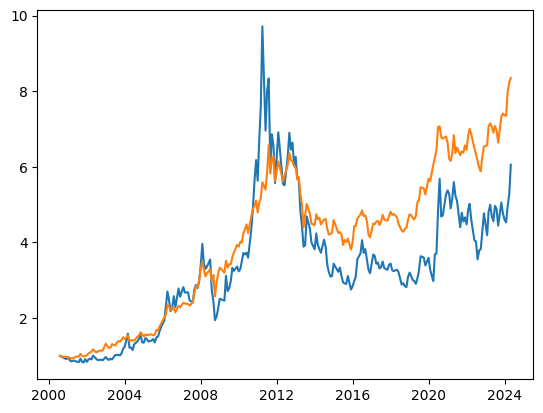

In [ ]:
import matplotlib.pyplot as plt
plt.plot(mydf.index, normalized_silver)
plt.plot(mydf.index, normalized_gold)

In [ ]:
score, pvalue, _ = coint(mydf['Gold'], mydf['Silver'])
print("Cointegration test p-value:", pvalue)

Cointegration test p-value: 0.511072755368923


In [ ]:
#Find stats.mean for periods of high confidence in the market
#Just as a contrast

In [ ]:
#As expected, without controlling for recessionary and expansionary periods, a stationary relationship is not conclusive

In [ ]:
recession_df_2001 = mydf.loc['2001-01-01':'2001-12-01']
score, pvalue, _ = coint(recession_df_2001['Gold'], recession_df_2001['Silver'])
print("Cointegration test p-value:", pvalue)

Cointegration test p-value: 0.9859002580259643


In [ ]:
stats.mean(recession_df_2001['S/G Ratio'])

0.01614570391528141

In [ ]:
stats.variance(recession_df_2001['S/G Ratio'])

8.684878912142898e-07

In [ ]:
recession_df_2008 = mydf.loc['2007-12-01':'2009-06-01']
score, pvalue, _ = coint(recession_df_2008['Gold'], recession_df_2008['Silver'])
print('Cointegration test p-value:', pvalue)

Cointegration test p-value: 0.9859002580259643


In [ ]:
stats.mean(recession_df_2008['S/G Ratio'])

0.016248770653708902

In [ ]:
stats.variance(recession_df_2008['S/G Ratio'])

7.3889224833853475e-06

In [ ]:
#So far, we're not getting great results
#Sample size may be a problem
#Let's cointegrate ratio vs interest rates

In [ ]:
score, pvalue, _ = coint(s_g_normalized, rates_normalized)
print("Cointegration test p-value:", pvalue)

Cointegration test p-value: 0.26347455131772235


In [ ]:
#We have a p-value of 0.15 for G/S and 0.26 for S/G, which doesn't reach alpha = 0.05, but is promising considering that a populated cointegrated pair:
#CocaCola and Pepsi only have a p-value of 0.3025. We can afford to raise our cutoff. It's evident that the ratio is directly dependent on interest rates, but that recessions aren't a predictor
#Of the actual ratio, since rates can be different during the recession.

In [ ]:
#Extra Figures and Stats

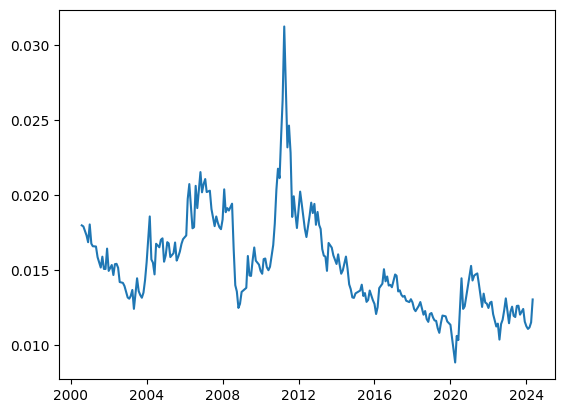

In [ ]:
import matplotlib.pyplot as plt
plt.plot(mydf.index, mydf['S/G Ratio'])

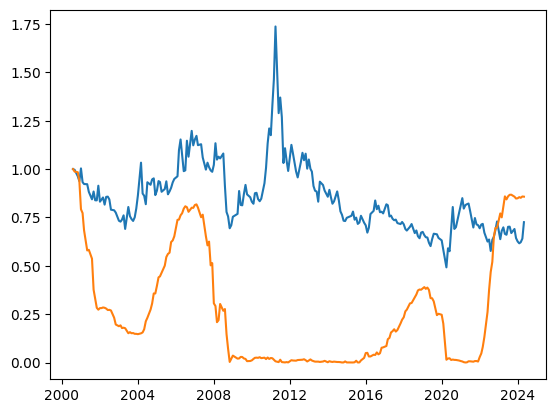

In [ ]:
import matplotlib.pyplot as plt
plt.plot(mydf.index, s_g_normalized, label = 'Ratio')
plt.plot(mydf.index, rates_normalized, label = 'Rates')
#Normalize this

In [ ]:
stats.correlation(mydf['Gold'], mydf['Silver'])

0.8625135481904153

In [ ]:
stats.correlation(mydf['Gold'], mydf['Rates'])

-0.2192311681825029

In [ ]:
stats.correlation(mydf['Silver'], mydf['Rates'])

-0.3178868057488006

In [ ]:
stats.correlation(s_g_normalized, rates_normalized)

0.02383797812115387

In [ ]:
#Cointegration Comparison w/ Coca and Pepsi Pair-

In [ ]:
Coca = yf.download("KO", start="2000-01-01", end="2025-01-01", auto_adjust= False, interval = '1mo')['Adj Close']
Pepsi = yf.download("PEP", start="2000-01-01", end="2025-01-01", auto_adjust= False, interval = '1mo')['Adj Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
test_df = pd.DataFrame()
test_df['Coke'] = Coca
test_df['Pepsi'] = Pepsi

In [ ]:
score, pvalue, _ = coint(test_df['Coke'], test_df['Pepsi'])
print("Cointegration test p-value:", pvalue)

Cointegration test p-value: 0.30247301367339713


In [ ]:
#Last step, I'm going to make combined series of s/g ratio in recession (with each set normalized first before combining)
#Then I'll see if my cointegration improves